In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Upload your CSV file

from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

for file in uploaded:
    print(file)

Saving seasonal_agriculture_performance_dataset (2).csv to seasonal_agriculture_performance_dataset (2).csv
File uploaded successfully!
seasonal_agriculture_performance_dataset (2).csv


In [3]:
# Find and load the CSV automatically

csv_file = None

for file in uploaded.keys():
    if file.lower().endswith(".csv"):
        csv_file = file
        break

if csv_file is None:
    raise Exception("Please upload a CSV file.")

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("File:", csv_file)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
File: seasonal_agriculture_performance_dataset (2).csv
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Display all column names

print("COLUMN NAMES")
print("=" * 50)

for i, column in enumerate(df.columns, 1):
    print(i, "->", column)

COLUMN NAMES
1 -> Farm_ID
2 -> State
3 -> District
4 -> Crop
5 -> Season
6 -> Farm_Area_Hectares
7 -> Rainfall_mm
8 -> Avg_Temperature_C
9 -> Humidity_pct
10 -> Sunlight_Hours_Day
11 -> Soil_pH
12 -> Soil_Moisture_pct
13 -> Nitrogen_kg_ha
14 -> Phosphorus_kg_ha
15 -> Potassium_kg_ha
16 -> Irrigation_Method
17 -> Fertilizer_kg_ha
18 -> Pesticide_Litre_ha
19 -> Seed_Quality_Score
20 -> Yield_Tonnes_Ha
21 -> Production_Tonnes
22 -> Market_Price_INR_Tonne
23 -> Total_Cost_INR
24 -> Revenue_INR
25 -> Profit_INR
26 -> Water_Used_m3
27 -> Water_Efficiency_t_per_1000m3
28 -> Disease_Pest_Risk_pct


In [5]:
# Dataset information

print("Dataset Shape:", df.shape)

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Information:")
df.info()

Dataset Shape: (4000, 28)

Data Types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [6]:
# Missing values

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

print("Total missing values:", df.isnull().sum().sum())

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Total missing values: 120


In [7]:
# Duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print("New dataset shape:", df.shape)

Number of duplicate rows: 0
New dataset shape: (4000, 28)


In [8]:
# Clean missing values

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

# Numeric columns -> median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns -> mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [9]:
# Numerical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [10]:
# Categorical summary

display(df.describe(include="object").T)

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [11]:
# Automatically find the Season column

season_column = None

for column in df.columns:
    if column.lower().strip() == "season":
        season_column = column
        break

if season_column is None:
    raise Exception("Season column was not found.")

print("Season column:", season_column)

print("\nSeason values:")
print(df[season_column].value_counts())

Season column: Season

Season values:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


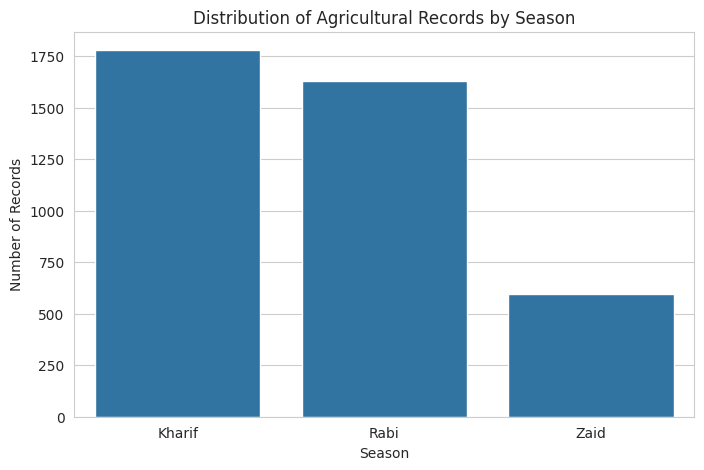

In [12]:
# Plot seasonal distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=season_column
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

In [13]:
# Find the yield column automatically

yield_column = None

for column in df.columns:
    name = column.lower().replace(" ", "_")

    if "yield" in name:
        yield_column = column
        break

print("Yield column detected:", yield_column)

if yield_column is None:
    print("WARNING: Yield column was not detected.")

Yield column detected: Yield_Tonnes_Ha


,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.63,1.94,0.3,101.44
Rabi,1627,5.04,1.67,0.3,93.13
Zaid,594,4.64,1.46,0.3,64.76


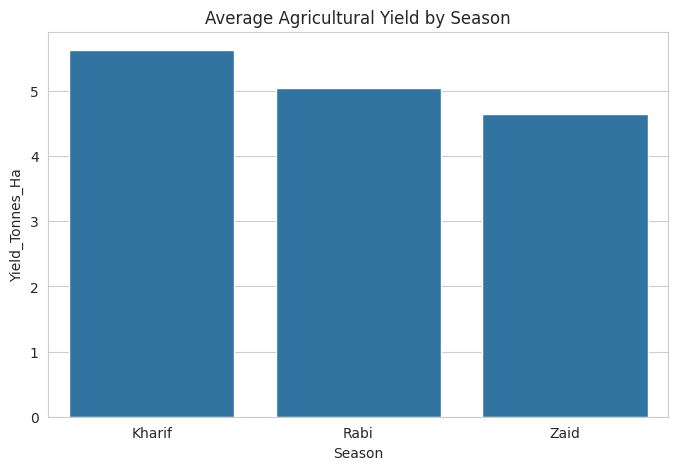

In [14]:
# Seasonal yield analysis

if yield_column is not None:

    seasonal_yield = df.groupby(season_column)[yield_column].agg(
        ["count", "mean", "median", "min", "max"]
    ).round(2)

    display(seasonal_yield)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df,
        x=season_column,
        y=yield_column,
        errorbar=None
    )

    plt.title("Average Agricultural Yield by Season")
    plt.xlabel("Season")
    plt.ylabel(yield_column)

    plt.show()

Production column: Production_Tonnes


,Average Production
Season,
Kharif,46.31
Rabi,41.49
Zaid,38.89


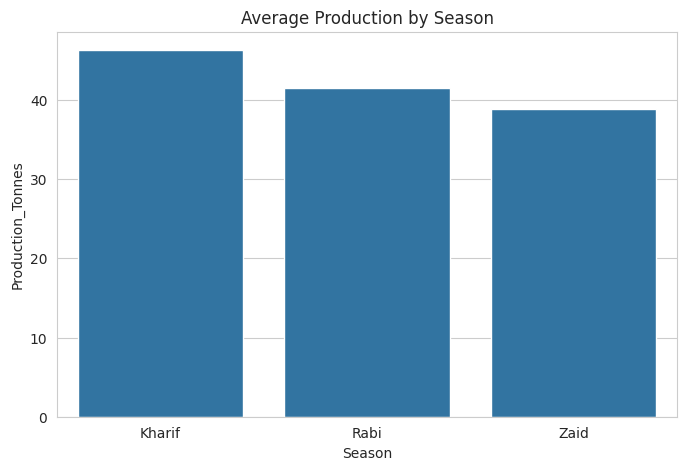

In [15]:
# Find production column

production_column = None

for column in df.columns:
    name = column.lower()

    if "production" in name:
        production_column = column
        break

print("Production column:", production_column)

if production_column:

    production_summary = df.groupby(
        season_column
    )[production_column].mean().round(2)

    display(production_summary.to_frame("Average Production"))

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df,
        x=season_column,
        y=production_column,
        errorbar=None
    )

    plt.title("Average Production by Season")
    plt.show()

Profit column: Profit_INR


,Average Profit
Season,
Kharif,178914.65
Rabi,87689.47
Zaid,-24804.82


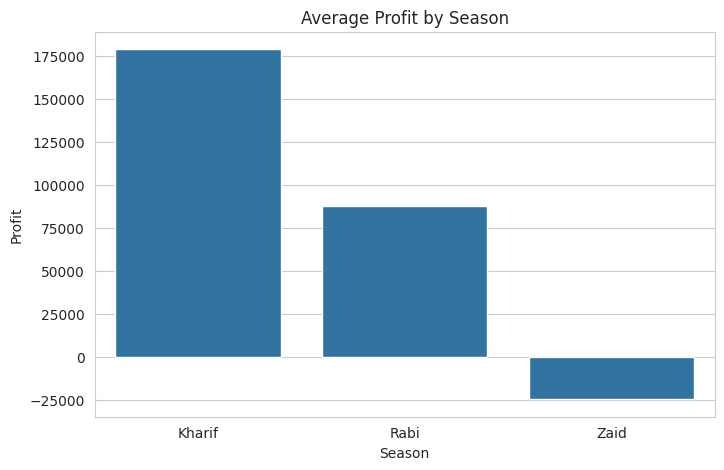

In [16]:
# Find profit column

profit_column = None

for column in df.columns:
    name = column.lower()

    if "profit" in name:
        profit_column = column
        break

print("Profit column:", profit_column)

if profit_column:

    profit_summary = df.groupby(
        season_column
    )[profit_column].mean().round(2)

    display(profit_summary.to_frame("Average Profit"))

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df,
        x=season_column,
        y=profit_column,
        errorbar=None
    )

    plt.title("Average Profit by Season")
    plt.ylabel("Profit")

    plt.show()

Crop column: Crop


,Average Yield
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


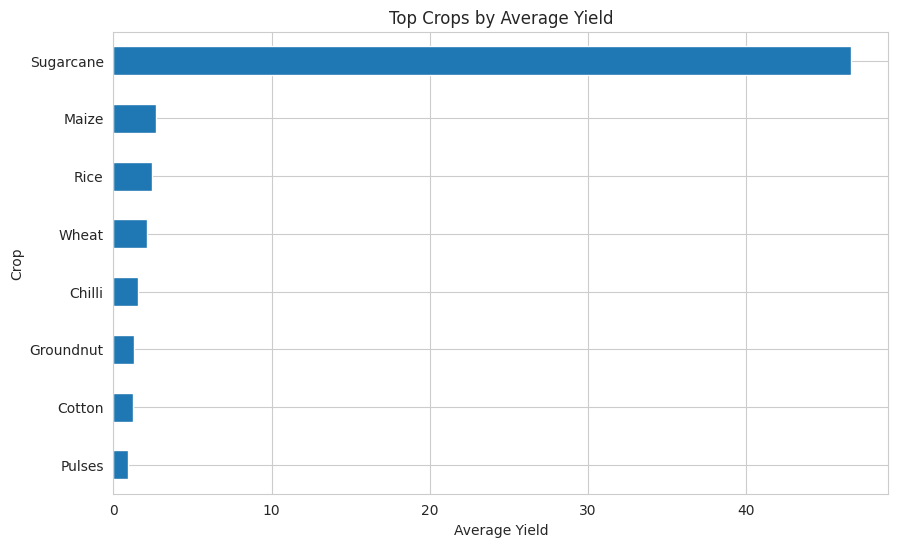

In [17]:
# Crop analysis

crop_column = None

for column in df.columns:
    name = column.lower()

    if name == "crop" or "crop" in name:
        crop_column = column
        break

print("Crop column:", crop_column)

if crop_column and yield_column:

    crop_yield = (
        df.groupby(crop_column)[yield_column]
        .mean()
        .sort_values(ascending=False)
        .round(2)
    )

    display(crop_yield.to_frame("Average Yield"))

    plt.figure(figsize=(10,6))

    crop_yield.head(15).sort_values().plot(kind="barh")

    plt.title("Top Crops by Average Yield")
    plt.xlabel("Average Yield")

    plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


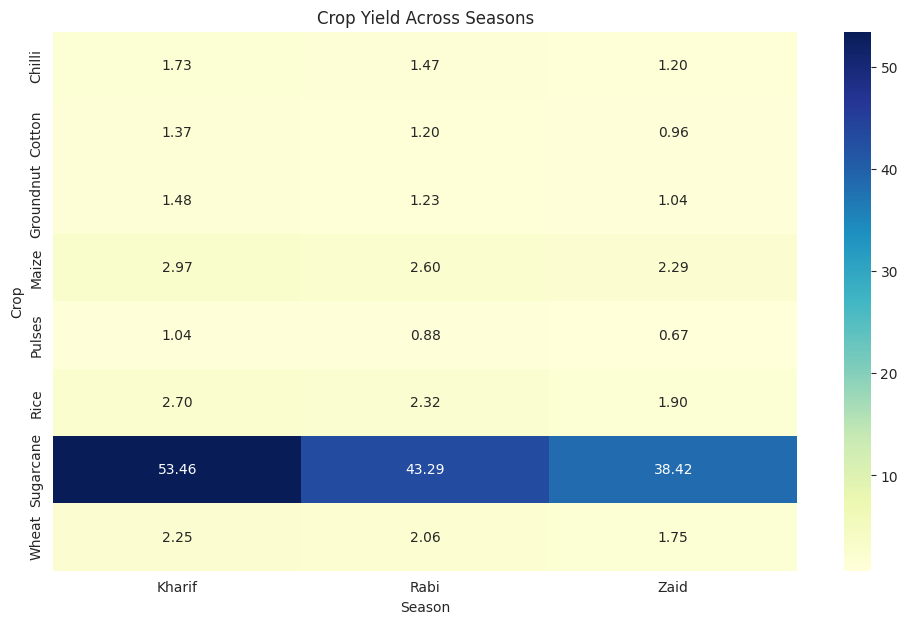

In [18]:
# Crop × Season analysis

if crop_column and yield_column:

    crop_season = pd.pivot_table(
        df,
        values=yield_column,
        index=crop_column,
        columns=season_column,
        aggfunc="mean"
    )

    display(crop_season.round(2))

    plt.figure(figsize=(12,7))

    sns.heatmap(
        crop_season,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title("Crop Yield Across Seasons")
    plt.xlabel("Season")
    plt.ylabel("Crop")

    plt.show()

In [20]:
# Environmental variables

environmental_keywords = [
    "rain",
    "temperature",
    "humidity",
    "sunlight",
    "soil_moisture",
    "soil moisture"
]

environmental_columns = []

for column in df.select_dtypes(include=np.number).columns:

    name = column.lower()

    if any(keyword in name for keyword in environmental_keywords):
        environmental_columns.append(column)

print("Environmental columns found:")
print(environmental_columns)

Environmental columns found:
['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


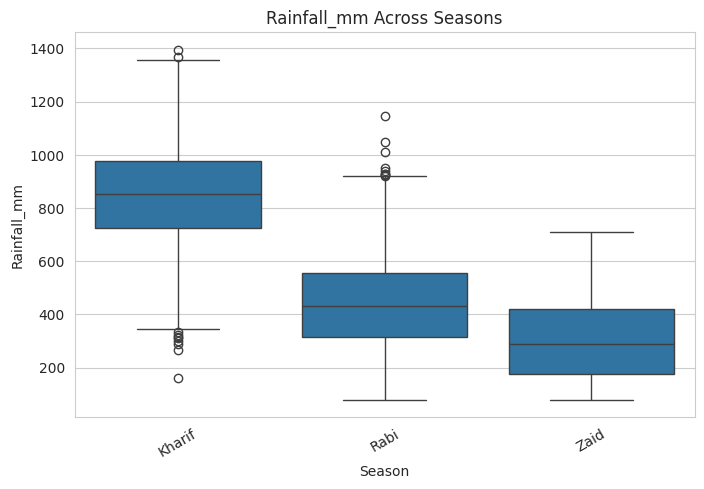

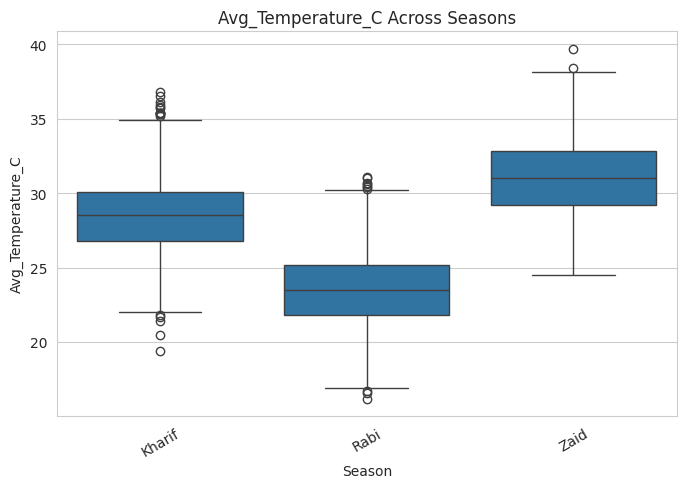

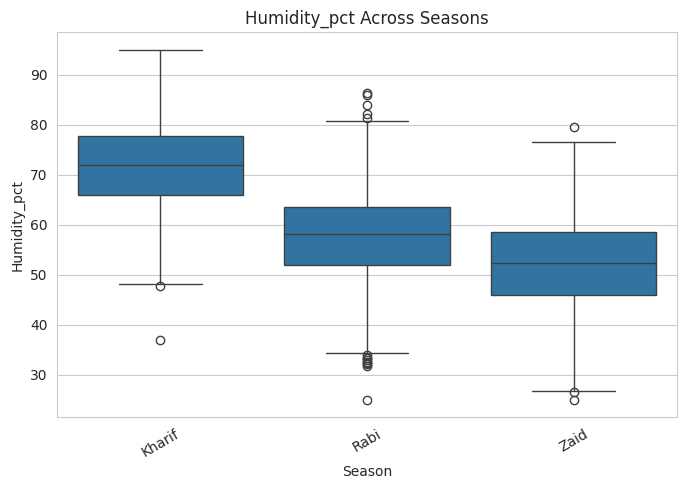

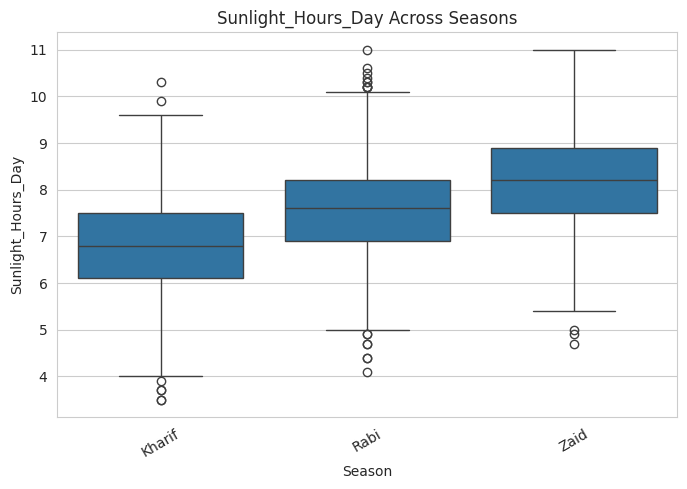

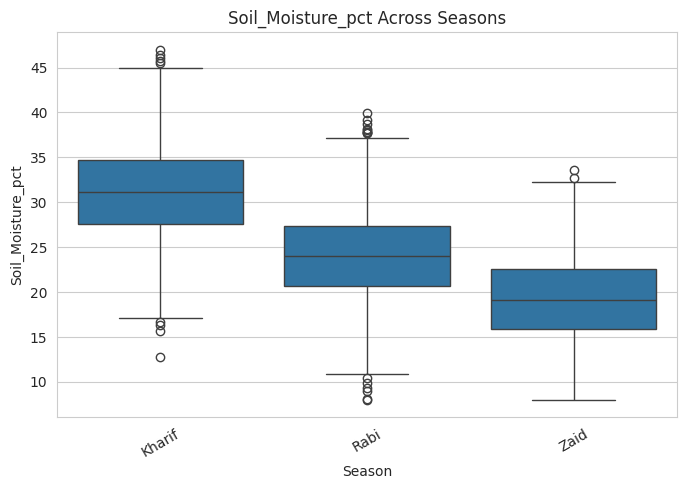

In [21]:
# Seasonal environmental analysis

if len(environmental_columns) > 0:

    environmental_summary = df.groupby(
        season_column
    )[environmental_columns].mean().round(2)

    display(environmental_summary)

    for column in environmental_columns:

        plt.figure(figsize=(8,5))

        sns.boxplot(
            data=df,
            x=season_column,
            y=column
        )

        plt.title(f"{column} Across Seasons")
        plt.xticks(rotation=30)

        plt.show()

In [22]:
# Resource usage analysis

resource_keywords = [
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "pesticide",
    "water"
]

resource_columns = []

for column in df.select_dtypes(include=np.number).columns:

    name = column.lower()

    if any(keyword in name for keyword in resource_keywords):
        resource_columns.append(column)

print("Resource columns found:")
print(resource_columns)

if resource_columns:

    resource_summary = df.groupby(
        season_column
    )[resource_columns].mean().round(2)

    display(resource_summary)

Resource columns found:
['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20,5.89
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99,5.19
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89,4.41


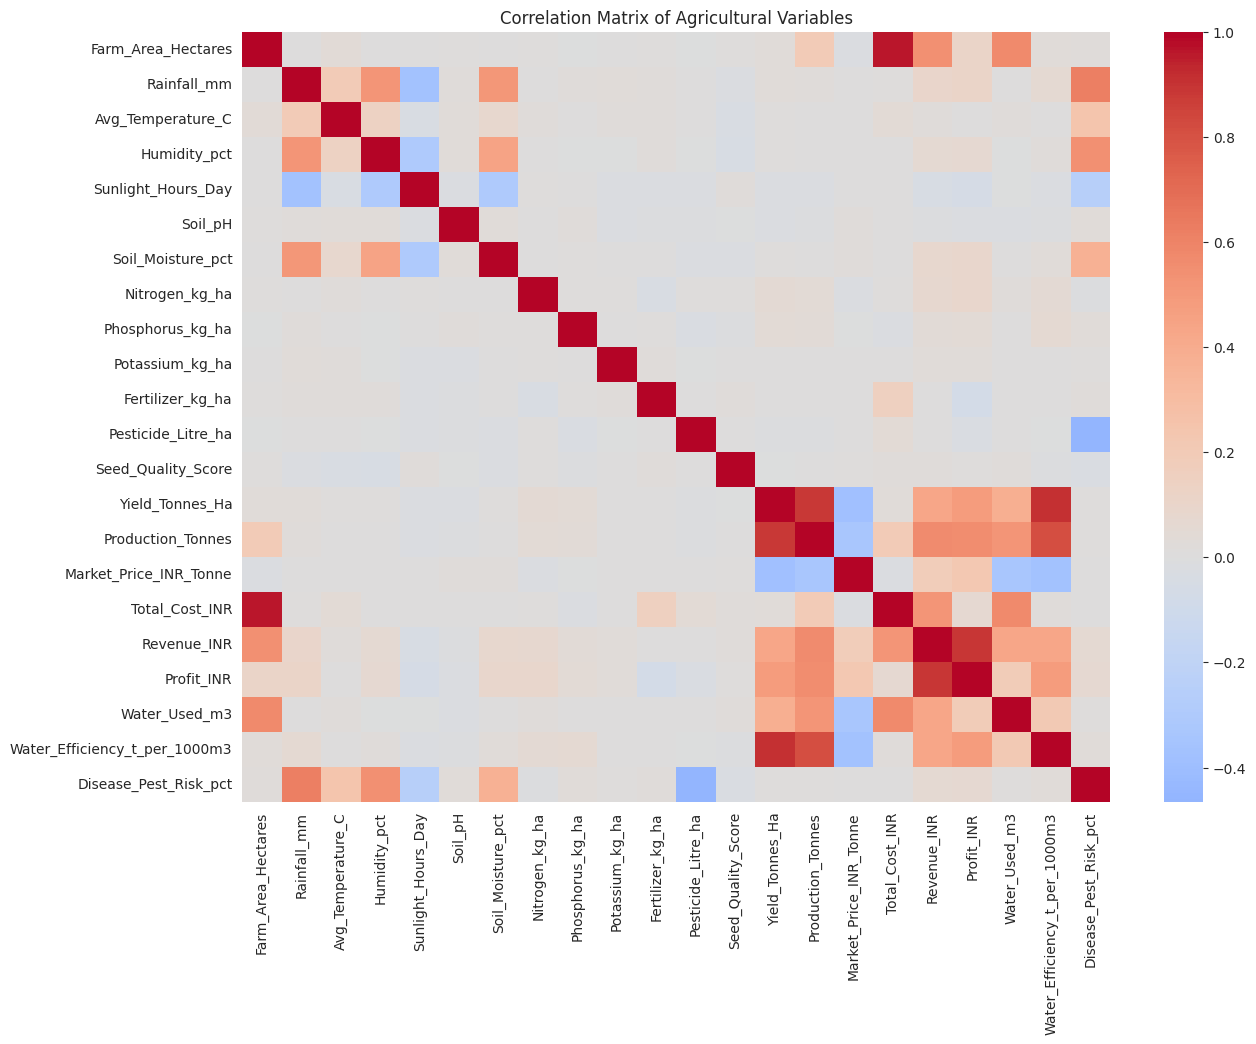

In [23]:
# Correlation analysis

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

In [24]:
# Variables most correlated with yield

if yield_column:

    yield_correlations = (
        numeric_df.corr()[yield_column]
        .sort_values(ascending=False)
    )

    print("Variables positively/negatively associated with yield:")

    display(
        yield_correlations.to_frame(
            "Correlation with Yield"
        )
    )

Variables positively/negatively associated with yield:


,Correlation with Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


Rainfall column: Rainfall_mm


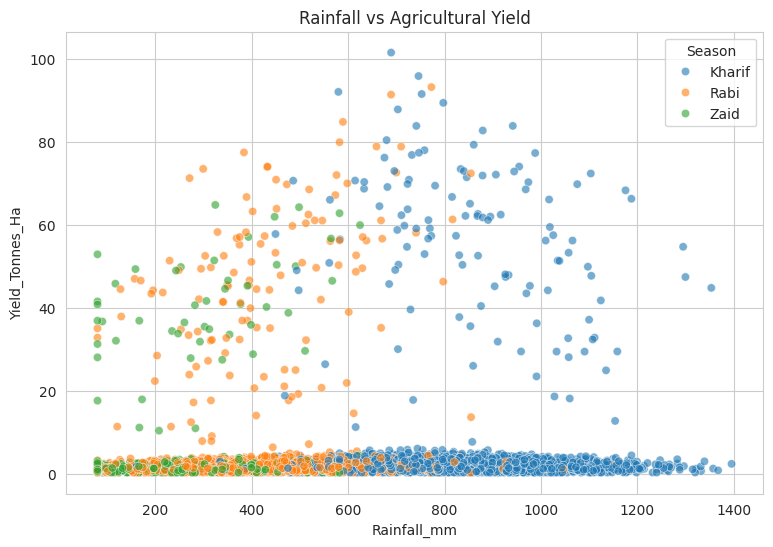

In [25]:
# Rainfall vs Yield

rainfall_column = None

for column in df.columns:

    if "rain" in column.lower():
        rainfall_column = column
        break

print("Rainfall column:", rainfall_column)

if rainfall_column and yield_column:

    plt.figure(figsize=(9,6))

    sns.scatterplot(
        data=df,
        x=rainfall_column,
        y=yield_column,
        hue=season_column,
        alpha=0.6
    )

    plt.title("Rainfall vs Agricultural Yield")
    plt.xlabel(rainfall_column)
    plt.ylabel(yield_column)

    plt.show()

In [26]:
# ANOVA test for seasonal yield differences

if yield_column:

    seasons = df[season_column].dropna().unique()

    groups = [
        df.loc[
            df[season_column] == season,
            yield_column
        ]
        for season in seasons
    ]

    anova = f_oneway(*groups)

    print("ANOVA TEST")
    print("=" * 40)
    print("F-statistic:", round(anova.statistic, 4))
    print("P-value:", round(anova.pvalue, 6))

    if anova.pvalue < 0.05:
        print("Conclusion: Seasonal yield differences are statistically significant.")
    else:
        print("Conclusion: Seasonal yield differences are not statistically significant.")

ANOVA TEST
F-statistic: 1.5439
P-value: 0.213678
Conclusion: Seasonal yield differences are not statistically significant.


Rainfall column: Rainfall_mm


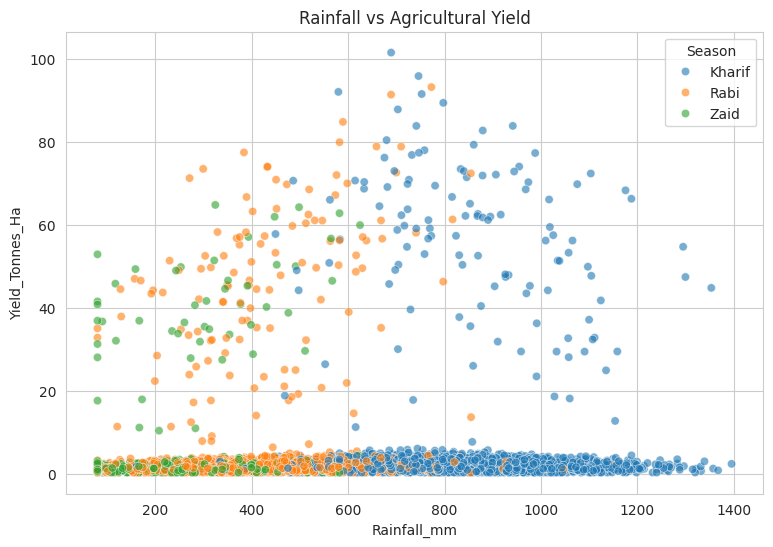

In [27]:
# Rainfall vs Yield

rainfall_column = None

for column in df.columns:

    if "rain" in column.lower():
        rainfall_column = column
        break

print("Rainfall column:", rainfall_column)

if rainfall_column and yield_column:

    plt.figure(figsize=(9,6))

    sns.scatterplot(
        data=df,
        x=rainfall_column,
        y=yield_column,
        hue=season_column,
        alpha=0.6
    )

    plt.title("Rainfall vs Agricultural Yield")
    plt.xlabel(rainfall_column)
    plt.ylabel(yield_column)

    plt.show()

In [28]:
# ANOVA test for seasonal yield differences

if yield_column:

    seasons = df[season_column].dropna().unique()

    groups = [
        df.loc[
            df[season_column] == season,
            yield_column
        ]
        for season in seasons
    ]

    anova = f_oneway(*groups)

    print("ANOVA TEST")
    print("=" * 40)
    print("F-statistic:", round(anova.statistic, 4))
    print("P-value:", round(anova.pvalue, 6))

    if anova.pvalue < 0.05:
        print("Conclusion: Seasonal yield differences are statistically significant.")
    else:
        print("Conclusion: Seasonal yield differences are not statistically significant.")

ANOVA TEST
F-statistic: 1.5439
P-value: 0.213678
Conclusion: Seasonal yield differences are not statistically significant.


In [29]:
# Tukey post-hoc test

if yield_column:

    tukey = pairwise_tukeyhsd(
        df[yield_column],
        df[season_column],
        alpha=0.05
    )

    print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Kharif   Rabi  -0.5892 0.4006 -1.6596 0.4813  False
Kharif   Zaid  -0.9873 0.2609 -2.4661 0.4915  False
  Rabi   Zaid  -0.3981  0.807 -1.8941 1.0978  False
---------------------------------------------------


In [30]:
# Chi-square test for categorical variables

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

if len(categorical_columns) >= 2:

    other_category = None

    for column in categorical_columns:

        if column != season_column:
            other_category = column
            break

    table = pd.crosstab(
        df[season_column],
        df[other_category]
    )

    print("\nContingency table:")
    display(table)

    chi2, p_value, dof, expected = chi2_contingency(table)

    print("Chi-square:", round(chi2,4))
    print("P-value:", round(p_value,6))

    if p_value < 0.05:
        print("Conclusion: Significant association detected.")
    else:
        print("Conclusion: No significant association detected.")

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Contingency table:


Farm_ID,SF10001,SF10002,SF10003,SF10004,SF10005,SF10006,SF10007,SF10008,SF10009,SF10010,...,SF13991,SF13992,SF13993,SF13994,SF13995,SF13996,SF13997,SF13998,SF13999,SF14000
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,1,1,0,1,0,0,0,1,0,0,...,1,0,0,0,1,1,1,0,1,1
Rabi,0,0,1,0,0,0,1,0,0,1,...,0,0,1,1,0,0,0,0,0,0
Zaid,0,0,0,0,1,1,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0


Chi-square: 8000.0
P-value: 0.49159
Conclusion: No significant association detected.


In [31]:
# Random Forest Yield Prediction

if yield_column:

    ml_df = df.copy()

    # Remove rows with missing target
    ml_df = ml_df.dropna(subset=[yield_column])

    # Use numeric columns only for a robust model
    numeric_features = [
        c for c in ml_df.select_dtypes(include=np.number).columns
        if c != yield_column
    ]

    if len(numeric_features) >= 2:

        X = ml_df[numeric_features]
        y = ml_df[yield_column]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42
        )

        rf = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        predictions = rf.predict(X_test)

        print("Random Forest model trained successfully.")

Random Forest model trained successfully.


MODEL PERFORMANCE
MAE : 0.62
RMSE: 2.1606
R²  : 0.9758

Most important variables:


,Feature,Importance
19,Water_Efficiency_t_per_1000m3,0.893082
17,Profit_INR,0.031402
13,Production_Tonnes,0.021649
5,Soil_pH,0.009582
0,Farm_Area_Hectares,0.009002
14,Market_Price_INR_Tonne,0.007850
1,Rainfall_mm,0.004230
15,Total_Cost_INR,0.003044
3,Humidity_pct,0.002745
9,Potassium_kg_ha,0.002707


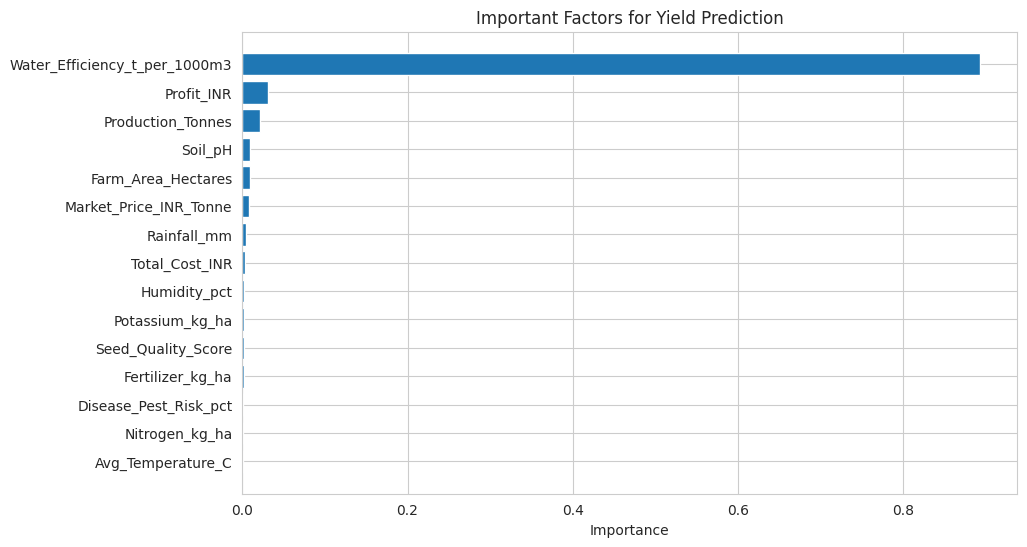

In [32]:
# Model evaluation + feature importance

if yield_column and 'rf' in locals():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print("MODEL PERFORMANCE")
    print("=" * 40)

    print("MAE :", round(mae,4))
    print("RMSE:", round(rmse,4))
    print("R²  :", round(r2,4))

    importance = pd.DataFrame({
        "Feature": numeric_features,
        "Importance": rf.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    print("\nMost important variables:")

    display(importance.head(15))

    plt.figure(figsize=(10,6))

    top = importance.head(15).sort_values("Importance")

    plt.barh(
        top["Feature"],
        top["Importance"]
    )

    plt.title("Important Factors for Yield Prediction")
    plt.xlabel("Importance")

    plt.show()

In [33]:
# FINAL AUTOMATIC PROJECT SUMMARY

print("=" * 70)
print("🌾 SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("FINAL RESULTS")
print("=" * 70)

# Season result
if yield_column:

    seasonal_mean = df.groupby(
        season_column
    )[yield_column].mean()

    best_season = seasonal_mean.idxmax()
    worst_season = seasonal_mean.idxmin()

    print("\n1. SEASONAL PERFORMANCE")
    print("Highest average yield:", best_season)
    print("Lowest average yield :", worst_season)

# Crop result
if crop_column and yield_column:

    crop_mean = df.groupby(
        crop_column
    )[yield_column].mean()

    best_crop = crop_mean.idxmax()

    print("\n2. CROP PERFORMANCE")
    print("Highest average-yield crop:", best_crop)

# Profit result
if profit_column:

    profit_mean = df.groupby(
        season_column
    )[profit_column].mean()

    print("\n3. ECONOMIC PERFORMANCE")
    print("Highest-profit season:", profit_mean.idxmax())
    print("Lowest-profit season :", profit_mean.idxmin())

# Statistical result
if yield_column:

    print("\n4. STATISTICAL FINDING")
    print("ANOVA p-value:", round(anova.pvalue, 6))

    if anova.pvalue < 0.05:
        print("Season has a statistically significant effect on yield.")
    else:
        print("Season does not show a statistically significant effect on yield.")

# ML result
if 'r2' in locals():

    print("\n5. MACHINE LEARNING")
    print("Random Forest R²:", round(r2,4))
    print("Random Forest MAE:", round(mae,4))

print("\n" + "=" * 70)
print("DATA-DRIVEN RECOMMENDATIONS")
print("=" * 70)

print("""
1. Seasonal agricultural planning should consider differences in
   observed yield and production across seasons.

2. Crops showing consistently higher performance should be studied
   further under their corresponding seasonal conditions.

3. Environmental and resource variables with strong relationships
   with yield should receive greater attention during farm planning.

4. Water and fertilizer usage should be evaluated together with
   agricultural output rather than independently.

5. Seasons with higher disease or pest risk should receive additional
   monitoring and preventive management.

6. Statistical results should be considered when deciding whether
   observed seasonal differences represent meaningful differences.

7. Unusual observations should be investigated rather than removed
   automatically.

8. The machine-learning feature importance results can help identify
   variables that deserve further agricultural investigation.
""")

print("=" * 70)
print("PROJECT ANALYSIS COMPLETED SUCCESSFULLY ✅")
print("=" * 70)

🌾 SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
FINAL RESULTS

1. SEASONAL PERFORMANCE
Highest average yield: Kharif
Lowest average yield : Zaid

2. CROP PERFORMANCE
Highest average-yield crop: Sugarcane

3. ECONOMIC PERFORMANCE
Highest-profit season: Kharif
Lowest-profit season : Zaid

4. STATISTICAL FINDING
ANOVA p-value: 0.213678
Season does not show a statistically significant effect on yield.

5. MACHINE LEARNING
Random Forest R²: 0.9758
Random Forest MAE: 0.62

DATA-DRIVEN RECOMMENDATIONS

1. Seasonal agricultural planning should consider differences in
   observed yield and production across seasons.

2. Crops showing consistently higher performance should be studied
   further under their corresponding seasonal conditions.

3. Environmental and resource variables with strong relationships
   with yield should receive greater attention during farm planning.

4. Water and fertilizer usage should be evaluated together with
   agricultural output rather than independently.

5. Seasons 